## Mod 6 Lecture 4 Data Challenge:  Simple Linear Regression

### Purpose

**Purpose**: Run a simple linear regression (SLR) on the NYC Yellow Taxi Dec 2023 excerpt to explain how a single input (X) relates to Tip % (Y). Practice picking a sensible X, fitting the line, and interpreting β₁, p‑value, and 95% confidence interval—plus basic assumption checks.

### Data
We are looking at ONE month's worth of data (December 2023 to be exact).  Remember the data dictionary is found [HERE](https://data.cityofnewyork.us/Transportation/2023-Yellow-Taxi-Trip-Data/4b4i-vvec/about_data)

### Instructor Guidance (10 Minutes)

#### Goals

- Pick an X with a plausible relationship to Tip % that is available at trip time.

- Communicate β₁ with units, p-vale, and a 95% CI.

#### Special considerations

- `Tip %` is `tip_amount / fare_amount`. Choosing `fare_amount` as X can create a built‑in relationship because it’s in the definition of Y (mathematical coupling). Encourage alternative X’s like `trip_distance`, `pickup_hour (as numeric)`, or `passenger_count`.

- Linearity check: Is the relationship roughly straight‑line? If X is discrete (e.g., passenger_count), SLR still works but discuss meaning.

- Intercept meaning: If X=0 is unrealistic (0 miles), say the intercept is just a mathematical anchor.

- Outliers: Large distances/fares can dominate. Consider trimming extremes thoughtfully or explaining how you would handle outliers.  

#### Critical thinking prompts as you work through the challenge (be prepared to answer at the end):

- Which input would you use to make a decision before the ride starts? Why?

- If β₁ is tiny but the p‑value is very small, is that useful for the business?

- If residuals (can only get residuals after fitting the model) "fan out" as X grows, what story might that tell about tipping behavior?

- Would your conclusion change if you looked at daytime vs. late night rides separately?

### Student Tasks (35 minutes)

Step 0 — Load Packages and Data, Fix Data Types, Create Tip % Column 

**Hint**:  You did this in the Code-Along, refer back to the notebook to help you!

In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures/Mod6/data/2023_Yellow_Taxi_Trip_Data_20251015.csv',low_memory=False)
df.head()
# cleaning data and changing datatype
num_cols = ['fare_amount', 'tip_amount']
for c in num_cols:
    df[c] = pd.to_numeric(df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'],errors= 'coerce')
    
df = df[(df['tip_amount']>0) & (df['fare_amount']>=0)]


Step 1 — Choose Your X (be sure to chose an X variable that would be available at trip time (not after the trip takes place))

Add a 2–3 sentence rationale in Markdown: Why could X relate to `tip_pct`? Why is it available **when the decision is made** (meaning driver has the information before the actual drive takes place)?

In [ ]:
# creating tip_pct column
df['tip_pct'] = (df['tip_amount'] / df['fare_amount']).clip(0,1)


- I will use pick_up hour as my X variable... I will extract the hour from the timestamp,and instead of using it as a simple numeric variable transformed to category 0-23,I will subset it with sine and cosine to catch the cyclic pattern from hours 0-23. Since hours repeat in a 24-hour cycle. Sine and cosine turn the hour into a circular pattern,so the model understands that 23 h and 0 h are next to each other, not far apart. 
- the X relate to tip_pct because I think, depending on time of the day, clients tend to tip more or less, associating the service delivered to the period of time. This is available before the drive takes place, so the driver could estimate how much tip he could expect by driving late nights or early morning for example.

In [15]:
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['hour'].value_counts()
df["hour_sin"] = np.sin(2 * np.pi * df['hour']/24)
df["hour_cos"] = np.cos(2 * np.pi * df['hour']/24)


Step 2 — Quick Visual Check (Linearity & Outliers)

Add a 2-3 sentence rationale on how you would handle outliers or how you did handle outliers (if you handled them for this challenge).  Is the linear relationship there between your X and Y?  Is it a strong relationship?  What is the benefits of a strong relationship between X and Y?

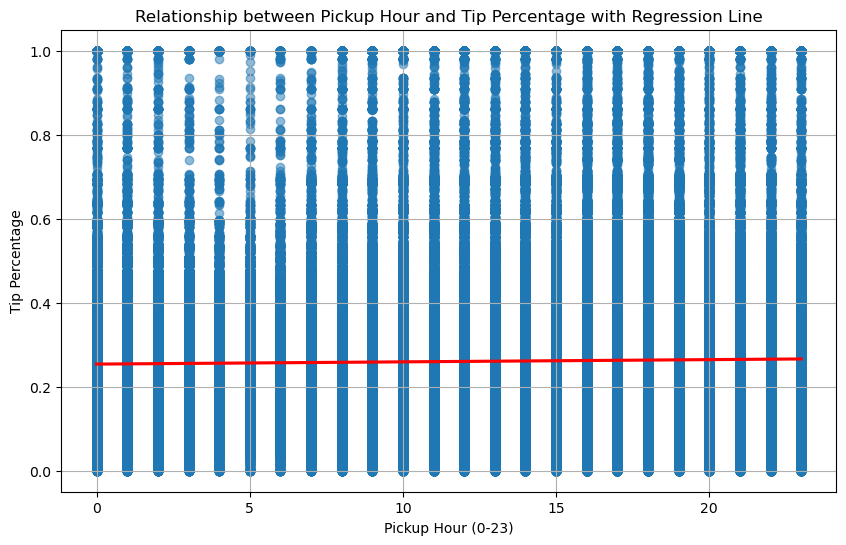

In [23]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='hour', y='tip_pct', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel('Pickup Hour (0-23)')
plt.ylabel('Tip Percentage')
plt.title('Relationship between Pickup Hour and Tip Percentage with Regression Line')
plt.grid(True)
plt.show()

**LINEARITY** a flat regression line shows that the relationship between X and Y is nearly none. we can suggest that there is no meaningful relationship between pick up hour and tip percentage.

Step 3 — Fit SLR Model to Data

In [18]:
X = sm.add_constant(df[['hour_sin','hour_cos']])
y = df['tip_pct']

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                tip_pct   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     3825.
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        13:50:33   Log-Likelihood:             2.2011e+06
No. Observations:             2462617   AIC:                        -4.402e+06
Df Residuals:                 2462614   BIC:                        -4.402e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2597   7.38e-05   3519.388      0.000       0.260       0.260
hour_sin      -0.0073      0.000    -70.148      0.000      -0.007      -0.007
hour_cos       0.0034   9.24e-05     36.479      0.000       0.003       0.004
==============================================================================
Omnibus:                   785796.955   Durbin-Watson:                   1.972
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          7758302.630
Skew:                           1.251   Prob(JB):                         0.00
Kurtosis:                      11.327   Cond. No.                         2.03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Step 4 — Interpret the model's coefficients, p-values, and CI 

Double-click cell to type in your answer

- P_value: nearly 0.00, very small, indicating the effect is significatif, but this is probably because of a huge sample size. with that much data, even a tiny effect can seems significatif
- Intercept: 0.25. meaning that the baseline tip percentage is approximately 25% in any hour of day
- the slopes hour sine, and hour cosine indicates the fluctuations of tip percentage through the day. since 3h and 5h have the same value in this context, we cannot say that for any additional hour, the Y variable will change by x_percent... however we can see for both directions "sine and cosine", the range is very small, indicating that the tip percentage fluctuates very little through the day, staying consistantly near the intercept...around 25% - 26%.
- Confidence interval: [0.025 - 0.975]. Although we have a statistically significance evidence that there is an effect of hour of day on tip percentage, this wide interval at 95% confidence shows uncertainty about the real effect... we can conclude that there is a statiscal difference but not a practifical significance, the effect is negligible.

Step 5 — Post‑Fit Assumption Glance 

Add 2-3 sentences about the residuals any curve? funnel shape? obvious outliers?  How would you go about checking if residuals were normally distributed?  

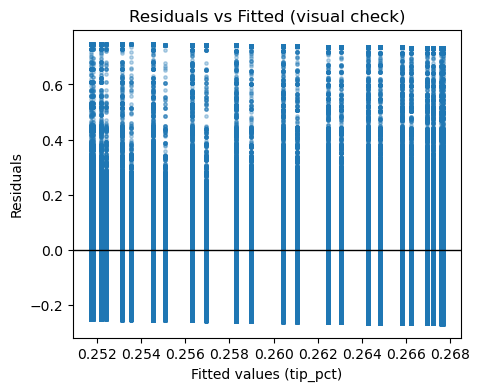

In [22]:
#RUN THIS CELL WITHOUT CHANGES
resid = model.resid
fitted = model.fittedvalues
plt.figure(figsize=(5,4))
plt.scatter(fitted, resid, s=6, alpha=0.3)
plt.axhline(0, color='k', lw=1)
plt.xlabel('Fitted values (tip_pct)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (visual check)')
plt.show()

### Reflection (10-15 mins)

**In addition to the critical thinking questions at the top** of the notebook be prepared to discuss: 

- If you had to make a decision tomorrow, would this simple model be enough? Why/why not?\
**Ans:** This model is informative, despite the uncertainty in our confidence interval, we have a sense of the effect that has hour of day on tip percentage, which we discovered is a very small effect. However, a small R_square, wide confidence interval, and the negligible effect detected make the model not reliable enough to be used as a decision making tool. Looking into more contributing variables to really determine what are the main drivers of trip percentage is recommended. 

- What’s one different X you’d try next and why?\
**Ans:** trip distance

#### Critical thinking prompts  (be prepared to answer at the end):

- Which input would you use to make a decision before the ride starts? Why?

*ans* Trip distance

- If β₁ is tiny but the p‑value is very small, is that useful for the business?

*ans* small pvalue indicates statistically significance, but the slope tells how practical is that, so depending on the business context, a small B1 could still be useful, but it has to be relative to the business.

- If residuals (can only get residuals after fitting the model) "fan out" as X grows, what story might that tell about tipping behavior?

* 
- Would your conclusion change if you looked at daytime vs. late night rides separately?

*ans* It's probable but I don't think so, the scatter plot shows similar pattern for all hours of the day, small variance, time pattern doesn't seem to explain much the tip percentage variation.